# 01. Thống kê và trực quan hóa cơ bản

## Đề tài: Phân tích và trực quan hóa dữ liệu du lịch Việt Nam

 


In [27]:
# 1. Import thư viện

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.io as pio

# Cấu hình Plotly
pio.renderers.default = "browser"

# Thiết lập hiển thị
pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}"
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [28]:
# 2. Đọc dữ liệu

import pandas as pd
from pathlib import Path

# Đường dẫn từ thư mục notebooks/ đến data/raw/
data_path = Path("../data/raw")

file_nam = data_path / "du_lieu_du_lich_nam.csv"
file_dia_phuong = data_path / "du_lieu_du_lich_dia_phuong.csv"

# Đọc dữ liệu
df_nam = pd.read_csv(file_nam)
df_dia_phuong = pd.read_csv(file_dia_phuong)

# Kiểm tra kích thước dữ liệu
print("Kích thước dữ liệu theo năm:", df_nam.shape)
print("Kích thước dữ liệu địa phương:", df_dia_phuong.shape)

Kích thước dữ liệu theo năm: (10, 12)
Kích thước dữ liệu địa phương: (700, 5)


## 3. Khảo sát tổng quan dữ liệu
 


In [29]:
# 3.1. Xem 5 dòng đầu
display(df_nam.head())
display(df_dia_phuong.head())


,Năm,Doanh thu cơ sở lưu trú (Tỷ đồng),Doanh thu cơ sở lữ hành (Tỷ đồng),Khách cơ sở lưu trú phục vụ (Nghìn lượt),Khách nghỉ qua đêm (Nghìn lượt),Khách trong ngày (Nghìn lượt),Khách trong nước - cơ sở lưu trú (Nghìn lượt),Khách quốc tế - cơ sở lưu trú (Nghìn lượt),Khách cơ sở lữ hành phục vụ (Nghìn lượt),Khách trong nước - cơ sở lữ hành (Nghìn lượt),Khách quốc tế - cơ sở lữ hành (Nghìn lượt),Khách Việt Nam đi nước ngoài (Nghìn lượt)
0,2015,"44,711.50","30,444.10","114,011.00",..,..,"102,200.00","11,811.00","12,601.70","9,288.70","2,820.00",493.00
1,2016,"48,524.60","32,530.30","129,735.20",..,..,"117,037.80","12,697.40","13,651.00","9,477.60","3,584.50",588.80
2,2017,"54,383.30","36,111.80","146,585.20",..,..,"132,837.90","13,747.30","15,173.00","9,918.40","4,556.40",698.30
3,2018,"59,202.20","40,371.20","159,640.60",..,..,"144,683.10","14,957.50","16,966.00","11,062.20","5,125.90",777.90
4,2019,"67,019.30","44,669.90","179,365.49",..,..,"162,046.62","17,318.87","18,366.29","11,791.16","5,730.28",844.85


,Địa phương,Cấp dữ liệu,Năm,Trạng thái,Doanh thu du lịch lữ hành (Tỷ đồng)
0,CẢ NƯỚC,Cả nước,2015,Chính thức,30444.1
1,CẢ NƯỚC,Cả nước,2016,Chính thức,32530.3
2,CẢ NƯỚC,Cả nước,2017,Chính thức,36111.8
3,CẢ NƯỚC,Cả nước,2018,Chính thức,40371.2
4,CẢ NƯỚC,Cả nước,2019,Chính thức,44669.9


In [30]:
# 3.2. Kích thước dữ liệu
print("Dataset theo năm:")
print(f"- Số dòng: {df_nam.shape[0]}")
print(f"- Số cột: {df_nam.shape[1]}")

print("\nDataset địa phương:")
print(f"- Số dòng: {df_dia_phuong.shape[0]}")
print(f"- Số cột: {df_dia_phuong.shape[1]}")


Dataset theo năm:
- Số dòng: 10
- Số cột: 12

Dataset địa phương:
- Số dòng: 700
- Số cột: 5


In [31]:
# 3.3. Thông tin kiểu dữ liệu
print("=== DATASET THEO NĂM ===")
df_nam.info()

print("\n=== DATASET ĐỊA PHƯƠNG ===")
df_dia_phuong.info()


=== DATASET THEO NĂM ===
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Năm                                            10 non-null     str    
 1   Doanh thu cơ sở lưu trú (Tỷ đồng)              10 non-null     float64
 2   Doanh thu cơ sở lữ hành (Tỷ đồng)              10 non-null     float64
 3   Khách cơ sở lưu trú phục vụ (Nghìn lượt)       10 non-null     float64
 4   Khách nghỉ qua đêm (Nghìn lượt)                10 non-null     str    
 5   Khách trong ngày (Nghìn lượt)                  10 non-null     str    
 6   Khách trong nước - cơ sở lưu trú (Nghìn lượt)  10 non-null     float64
 7   Khách quốc tế - cơ sở lưu trú (Nghìn lượt)     10 non-null     float64
 8   Khách cơ sở lữ hành phục vụ (Nghìn lượt)       10 non-null     float64
 9   Khách trong nước - cơ sở lữ hành (Nghìn lượ

In [32]:
# 3.4. Kiểm tra giá trị null
print("Giá trị null - dataset theo năm:")
display(df_nam.isnull().sum().to_frame("Số lượng"))

print("Giá trị null - dataset địa phương:")
display(df_dia_phuong.isnull().sum().to_frame("Số lượng"))


Giá trị null - dataset theo năm:


,Số lượng
Năm,0
Doanh thu cơ sở lưu trú (Tỷ đồng),0
Doanh thu cơ sở lữ hành (Tỷ đồng),0
Khách cơ sở lưu trú phục vụ (Nghìn lượt),0
Khách nghỉ qua đêm (Nghìn lượt),0
Khách trong ngày (Nghìn lượt),0
Khách trong nước - cơ sở lưu trú (Nghìn lượt),0
Khách quốc tế - cơ sở lưu trú (Nghìn lượt),0
Khách cơ sở lữ hành phục vụ (Nghìn lượt),0
Khách trong nước - cơ sở lữ hành (Nghìn lượt),0


Giá trị null - dataset địa phương:


,Số lượng
Địa phương,0
Cấp dữ liệu,0
Năm,0
Trạng thái,0
Doanh thu du lịch lữ hành (Tỷ đồng),0


In [33]:
# 3.5. Kiểm tra các ký hiệu đặc biệt như '..'
def special_value_report(df):
    result = {}
    for col in df.columns:
        result[col] = int((df[col].astype(str).str.strip() == "..").sum())
    return pd.Series(result).sort_values(ascending=False)

print("Số giá trị '..' theo cột - dataset theo năm:")
display(special_value_report(df_nam).to_frame("Số giá trị '..'"))

print("Số giá trị '..' theo cột - dataset địa phương:")
display(special_value_report(df_dia_phuong).to_frame("Số giá trị '..'"))


Số giá trị '..' theo cột - dataset theo năm:


,Số giá trị '..'
Khách trong ngày (Nghìn lượt),6
Khách nghỉ qua đêm (Nghìn lượt),6
Năm,0
Doanh thu cơ sở lưu trú (Tỷ đồng),0
Khách cơ sở lưu trú phục vụ (Nghìn lượt),0
Doanh thu cơ sở lữ hành (Tỷ đồng),0
Khách trong nước - cơ sở lưu trú (Nghìn lượt),0
Khách quốc tế - cơ sở lưu trú (Nghìn lượt),0
Khách cơ sở lữ hành phục vụ (Nghìn lượt),0
Khách trong nước - cơ sở lữ hành (Nghìn lượt),0


Số giá trị '..' theo cột - dataset địa phương:


,Số giá trị '..'
Doanh thu du lịch lữ hành (Tỷ đồng),12
Địa phương,0
Cấp dữ liệu,0
Năm,0
Trạng thái,0


In [34]:
# 3.6. Kiểm tra bản ghi trùng lặp
print("Số dòng trùng lặp - dataset theo năm:", df_nam.duplicated().sum())
print("Số dòng trùng lặp - dataset địa phương:", df_dia_phuong.duplicated().sum())


Số dòng trùng lặp - dataset theo năm: 0
Số dòng trùng lặp - dataset địa phương: 0


## 4. Làm sạch và chuẩn hóa dữ liệu
 


In [35]:
# 4.1. Thay '..' bằng NaN
df_nam_clean = df_nam.replace(r"^\s*\.\.\s*$", np.nan, regex=True).copy()
df_dia_phuong_clean = df_dia_phuong.replace(r"^\s*\.\.\s*$", np.nan, regex=True).copy()

# 4.2. Chuyển các cột có thể là số sang numeric nếu tên cột phù hợp
for df in [df_nam_clean, df_dia_phuong_clean]:
    for col in df.columns:
        if col != "Năm":
            converted = pd.to_numeric(df[col], errors="coerce")
            # Chỉ thay cột nếu việc chuyển đổi tạo ra phần lớn dữ liệu số
            non_null_original = df[col].notna().sum()
            non_null_converted = converted.notna().sum()
            if non_null_original > 0 and non_null_converted / non_null_original >= 0.7:
                df[col] = converted

# Chuẩn hóa năm
for df in [df_nam_clean, df_dia_phuong_clean]:
    if "Năm" in df.columns:
        df["Năm"] = pd.to_numeric(df["Năm"], errors="coerce").astype("Int64")

print("Kiểu dữ liệu sau chuẩn hóa - theo năm:")
display(df_nam_clean.dtypes.to_frame("dtype"))

print("Kiểu dữ liệu sau chuẩn hóa - địa phương:")
display(df_dia_phuong_clean.dtypes.to_frame("dtype"))


Kiểu dữ liệu sau chuẩn hóa - theo năm:


,dtype
Năm,Int64
Doanh thu cơ sở lưu trú (Tỷ đồng),float64
Doanh thu cơ sở lữ hành (Tỷ đồng),float64
Khách cơ sở lưu trú phục vụ (Nghìn lượt),float64
Khách nghỉ qua đêm (Nghìn lượt),float64
Khách trong ngày (Nghìn lượt),float64
Khách trong nước - cơ sở lưu trú (Nghìn lượt),float64
Khách quốc tế - cơ sở lưu trú (Nghìn lượt),float64
Khách cơ sở lữ hành phục vụ (Nghìn lượt),float64
Khách trong nước - cơ sở lữ hành (Nghìn lượt),float64


Kiểu dữ liệu sau chuẩn hóa - địa phương:


,dtype
Địa phương,str
Cấp dữ liệu,str
Năm,Int64
Trạng thái,str
Doanh thu du lịch lữ hành (Tỷ đồng),float64


In [36]:
# 4.3. Kiểm tra lại dữ liệu sau làm sạch
print("Null sau khi xử lý '..' - theo năm:")
display(df_nam_clean.isnull().sum().to_frame("Số lượng"))

print("Null sau khi xử lý '..' - địa phương:")
display(df_dia_phuong_clean.isnull().sum().to_frame("Số lượng"))


Null sau khi xử lý '..' - theo năm:


,Số lượng
Năm,1
Doanh thu cơ sở lưu trú (Tỷ đồng),0
Doanh thu cơ sở lữ hành (Tỷ đồng),0
Khách cơ sở lưu trú phục vụ (Nghìn lượt),0
Khách nghỉ qua đêm (Nghìn lượt),6
Khách trong ngày (Nghìn lượt),6
Khách trong nước - cơ sở lưu trú (Nghìn lượt),0
Khách quốc tế - cơ sở lưu trú (Nghìn lượt),0
Khách cơ sở lữ hành phục vụ (Nghìn lượt),0
Khách trong nước - cơ sở lữ hành (Nghìn lượt),0


Null sau khi xử lý '..' - địa phương:


,Số lượng
Địa phương,0
Cấp dữ liệu,0
Năm,0
Trạng thái,0
Doanh thu du lịch lữ hành (Tỷ đồng),12


## 5. Thống kê mô tả

Thống kê mô tả giúp nhận biết quy mô, mức trung bình, độ phân tán và khoảng biến thiên của các chỉ tiêu.


In [37]:
# 5.1. Thống kê mô tả dataset theo năm
display(df_nam_clean.describe(include="all").T)


,count,mean,std,min,25%,50%,75%,max
Năm,9.00,"2,019.00",2.74,"2,015.00","2,017.00","2,019.00","2,021.00","2,023.00"
Doanh thu cơ sở lưu trú (Tỷ đồng),10.00,"56,485.55","19,871.98","23,690.44","45,664.78","56,039.98","65,065.03","94,101.41"
Doanh thu cơ sở lữ hành (Tỷ đồng),10.00,"39,614.99","20,566.03","8,998.84","30,965.65","38,241.50","44,378.80","78,990.47"
Khách cơ sở lưu trú phục vụ (Nghìn lượt),10.00,"150,206.24","56,717.87","63,602.71","117,942.05","151,872.92","174,434.27","251,896.82"
Khách nghỉ qua đêm (Nghìn lượt),4.00,"132,084.16","66,953.68","43,831.51","100,677.45","143,673.04","175,079.75","197,159.04"
Khách trong ngày (Nghìn lượt),4.00,"39,772.64","15,076.90","19,771.19","33,093.71","42,290.79","48,969.71","54,737.78"
Khách trong nước - cơ sở lưu trú (Nghìn lượt),10.00,"130,706.90","41,813.77","60,453.24","105,909.45","137,967.27","157,705.74","192,273.00"
Khách quốc tế - cơ sở lưu trú (Nghìn lượt),10.00,"19,499.33","17,188.07","3,149.47","12,032.60","13,905.65","16,728.53","59,623.76"
Khách cơ sở lữ hành phục vụ (Nghìn lượt),10.00,"16,664.12","8,971.07","3,565.28","12,864.03","15,160.04","18,016.22","34,371.22"
Khách trong nước - cơ sở lữ hành (Nghìn lượt),10.00,"11,678.72","5,937.41","3,316.95","9,335.93","10,490.30","12,845.88","22,968.48"


In [38]:
# 5.2. Thống kê mô tả dataset địa phương
display(df_dia_phuong_clean.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Địa phương,700,70,CẢ NƯỚC,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cấp dữ liệu,700,3,Tỉnh/thành,630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Năm,700.00,<NA>,<NA>,<NA>,"2,019.50",2.87,"2,015.00","2,017.00","2,019.50","2,022.00","2,024.00"
Trạng thái,700,2,Chính thức,630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doanh thu du lịch lữ hành (Tỷ đồng),688.00,NaN,NaN,NaN,"1,727.40","6,744.71",0.02,12.00,41.11,211.33,"78,990.47"


## 6. Phân tích dữ liệu theo thời gian

Dataset theo năm có phạm vi 2015–2024. Nhóm tập trung quan sát xu hướng lượng khách và doanh thu, đồng thời chú ý giai đoạn suy giảm 2020–2021 và phục hồi từ 2022.


In [39]:
# 6.1. Xu hướng các chỉ tiêu theo năm
print("Các cột khách:", ['Khách cơ sở lưu trú phục vụ (Nghìn lượt)', 'Khách nghỉ qua đêm (Nghìn lượt)', 'Khách trong ngày (Nghìn lượt)', 'Khách trong nước - cơ sở lưu trú (Nghìn lượt)', 'Khách quốc tế - cơ sở lưu trú (Nghìn lượt)', 'Khách cơ sở lữ hành phục vụ (Nghìn lượt)', 'Khách trong nước - cơ sở lữ hành (Nghìn lượt)', 'Khách quốc tế - cơ sở lữ hành (Nghìn lượt)', 'Khách Việt Nam đi nước ngoài (Nghìn lượt)'])
print("Các cột doanh thu:", ['Doanh thu cơ sở lưu trú (Tỷ đồng)', 'Doanh thu cơ sở lữ hành (Tỷ đồng)'])


Các cột khách: ['Khách cơ sở lưu trú phục vụ (Nghìn lượt)', 'Khách nghỉ qua đêm (Nghìn lượt)', 'Khách trong ngày (Nghìn lượt)', 'Khách trong nước - cơ sở lưu trú (Nghìn lượt)', 'Khách quốc tế - cơ sở lưu trú (Nghìn lượt)', 'Khách cơ sở lữ hành phục vụ (Nghìn lượt)', 'Khách trong nước - cơ sở lữ hành (Nghìn lượt)', 'Khách quốc tế - cơ sở lữ hành (Nghìn lượt)', 'Khách Việt Nam đi nước ngoài (Nghìn lượt)']
Các cột doanh thu: ['Doanh thu cơ sở lưu trú (Tỷ đồng)', 'Doanh thu cơ sở lữ hành (Tỷ đồng)']


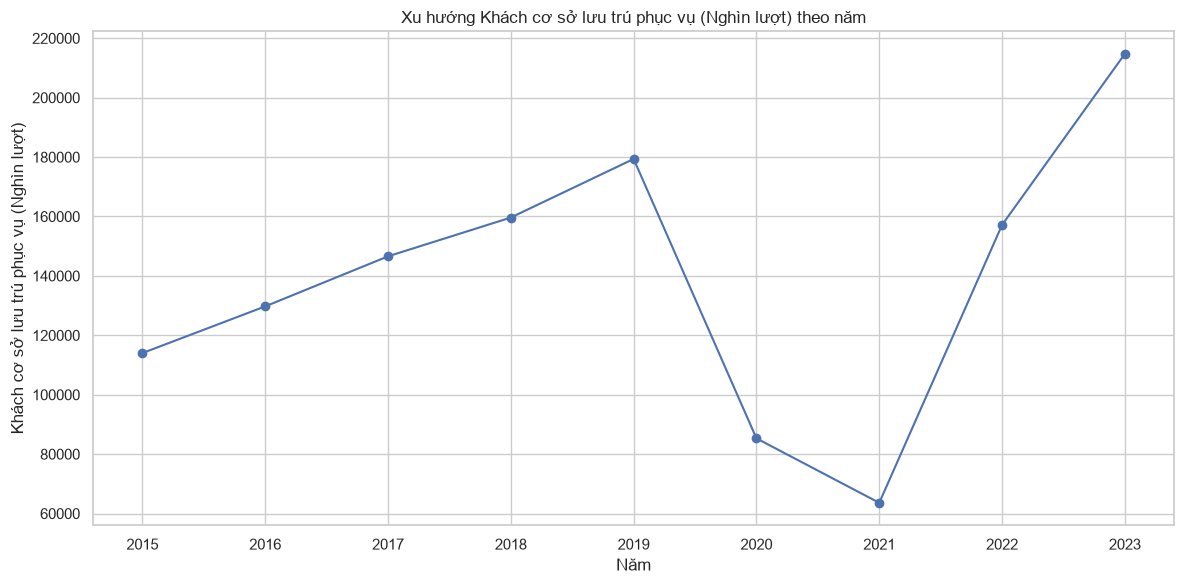

In [40]:
# Xu hướng: Khách cơ sở lưu trú phục vụ (Nghìn lượt)
plt.figure(figsize=(12,6))
plt.plot(df_nam_clean["Năm"], df_nam_clean["Khách cơ sở lưu trú phục vụ (Nghìn lượt)"], marker="o")
plt.title("Xu hướng Khách cơ sở lưu trú phục vụ (Nghìn lượt) theo năm")
plt.xlabel("Năm")
plt.ylabel("Khách cơ sở lưu trú phục vụ (Nghìn lượt)")
plt.xticks(df_nam_clean["Năm"].dropna().astype(int))
plt.tight_layout()
plt.show()


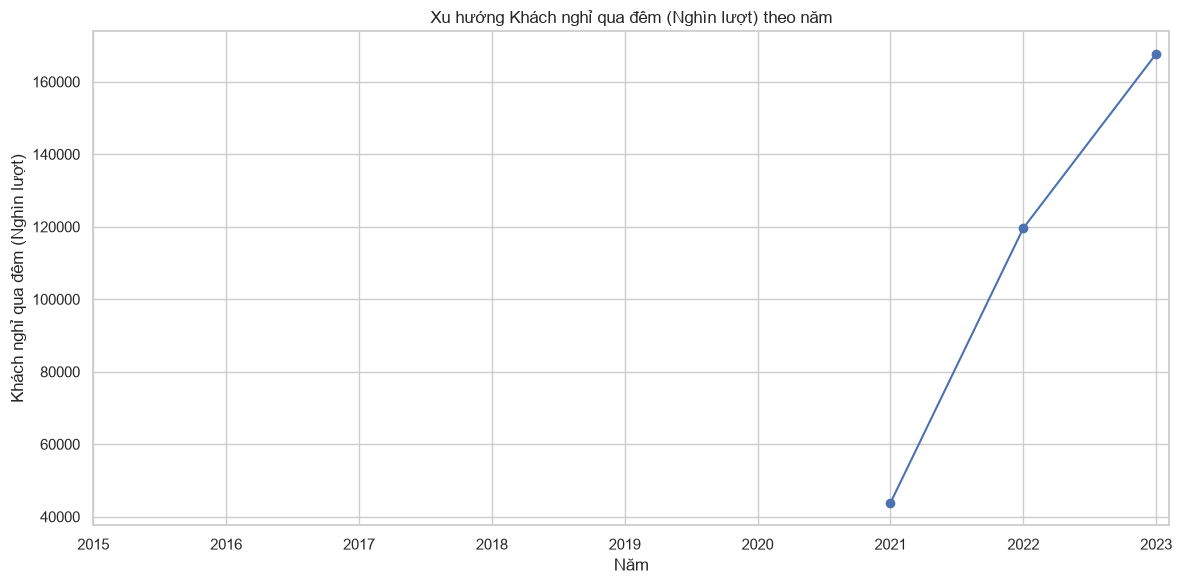

In [41]:
# Xu hướng: Khách nghỉ qua đêm (Nghìn lượt)
plt.figure(figsize=(12,6))
plt.plot(df_nam_clean["Năm"], df_nam_clean["Khách nghỉ qua đêm (Nghìn lượt)"], marker="o")
plt.title("Xu hướng Khách nghỉ qua đêm (Nghìn lượt) theo năm")
plt.xlabel("Năm")
plt.ylabel("Khách nghỉ qua đêm (Nghìn lượt)")
plt.xticks(df_nam_clean["Năm"].dropna().astype(int))
plt.tight_layout()
plt.show()


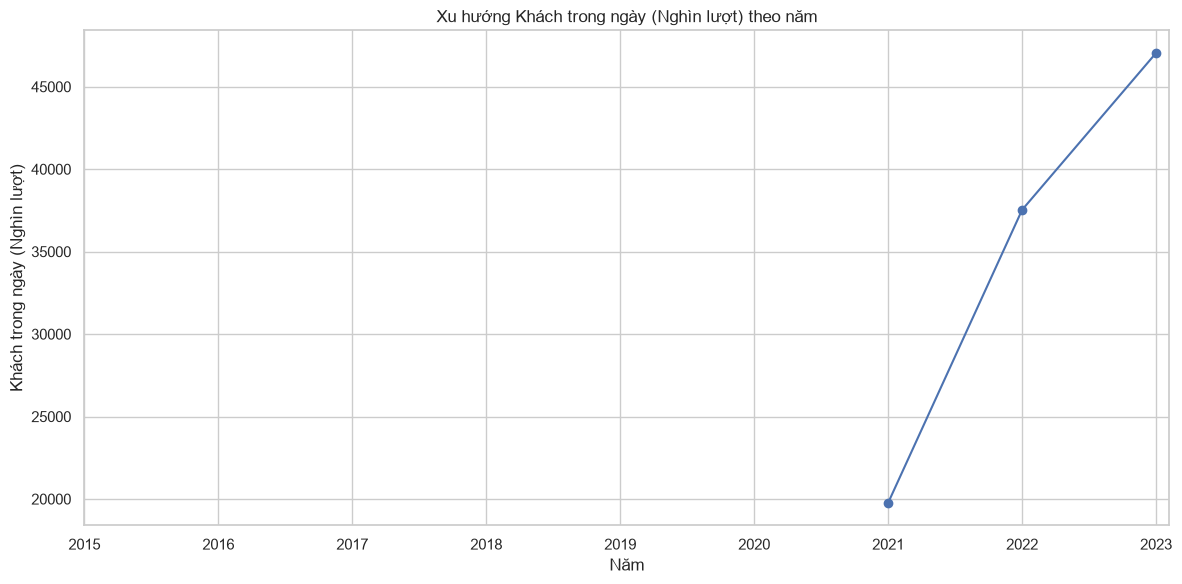

In [42]:
# Xu hướng: Khách trong ngày (Nghìn lượt)
plt.figure(figsize=(12,6))
plt.plot(df_nam_clean["Năm"], df_nam_clean["Khách trong ngày (Nghìn lượt)"], marker="o")
plt.title("Xu hướng Khách trong ngày (Nghìn lượt) theo năm")
plt.xlabel("Năm")
plt.ylabel("Khách trong ngày (Nghìn lượt)")
plt.xticks(df_nam_clean["Năm"].dropna().astype(int))
plt.tight_layout()
plt.show()


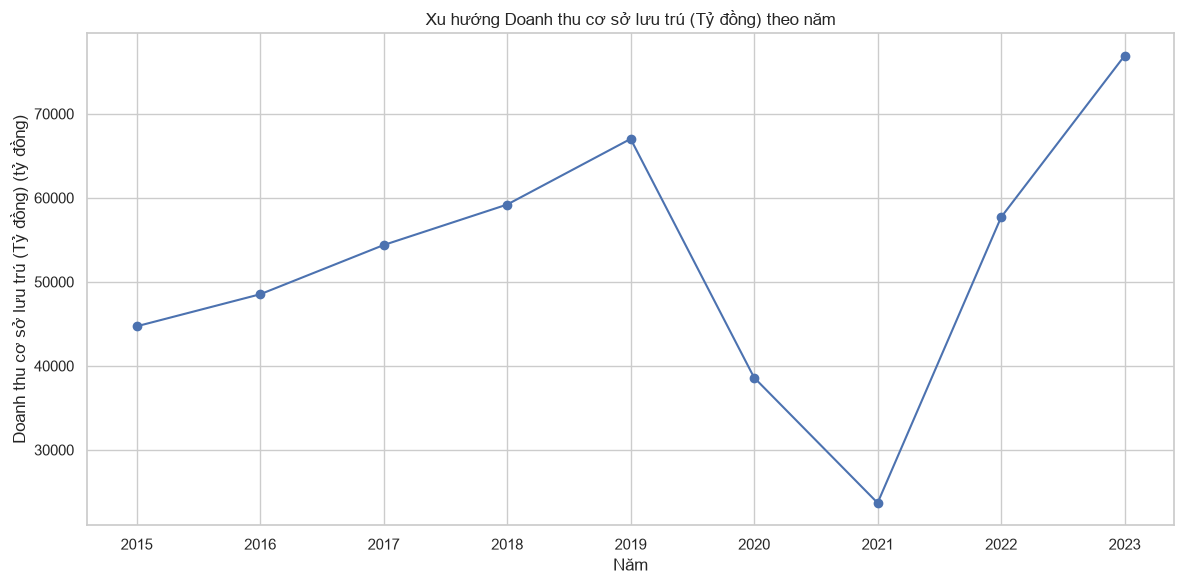

In [43]:
# Xu hướng doanh thu: Doanh thu cơ sở lưu trú (Tỷ đồng)
plt.figure(figsize=(12,6))
plt.plot(df_nam_clean["Năm"], df_nam_clean["Doanh thu cơ sở lưu trú (Tỷ đồng)"], marker="o")
plt.title("Xu hướng Doanh thu cơ sở lưu trú (Tỷ đồng) theo năm")
plt.xlabel("Năm")
plt.ylabel("Doanh thu cơ sở lưu trú (Tỷ đồng) (tỷ đồng)")
plt.xticks(df_nam_clean["Năm"].dropna().astype(int))
plt.tight_layout()
plt.show()


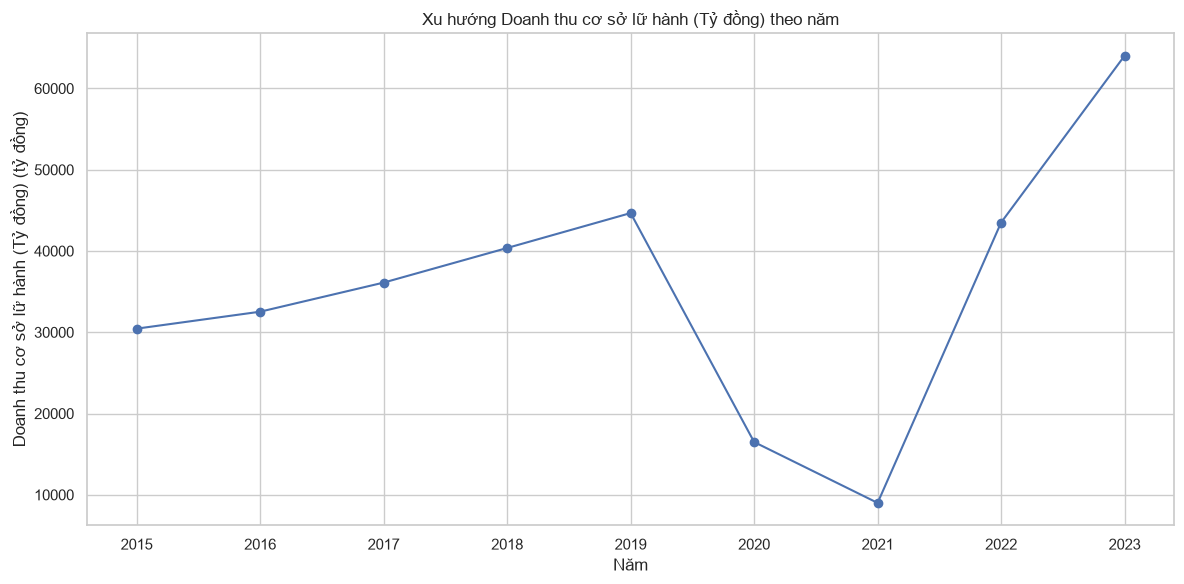

In [44]:
# Xu hướng doanh thu: Doanh thu cơ sở lữ hành (Tỷ đồng)
plt.figure(figsize=(12,6))
plt.plot(df_nam_clean["Năm"], df_nam_clean["Doanh thu cơ sở lữ hành (Tỷ đồng)"], marker="o")
plt.title("Xu hướng Doanh thu cơ sở lữ hành (Tỷ đồng) theo năm")
plt.xlabel("Năm")
plt.ylabel("Doanh thu cơ sở lữ hành (Tỷ đồng) (tỷ đồng)")
plt.xticks(df_nam_clean["Năm"].dropna().astype(int))
plt.tight_layout()
plt.show()


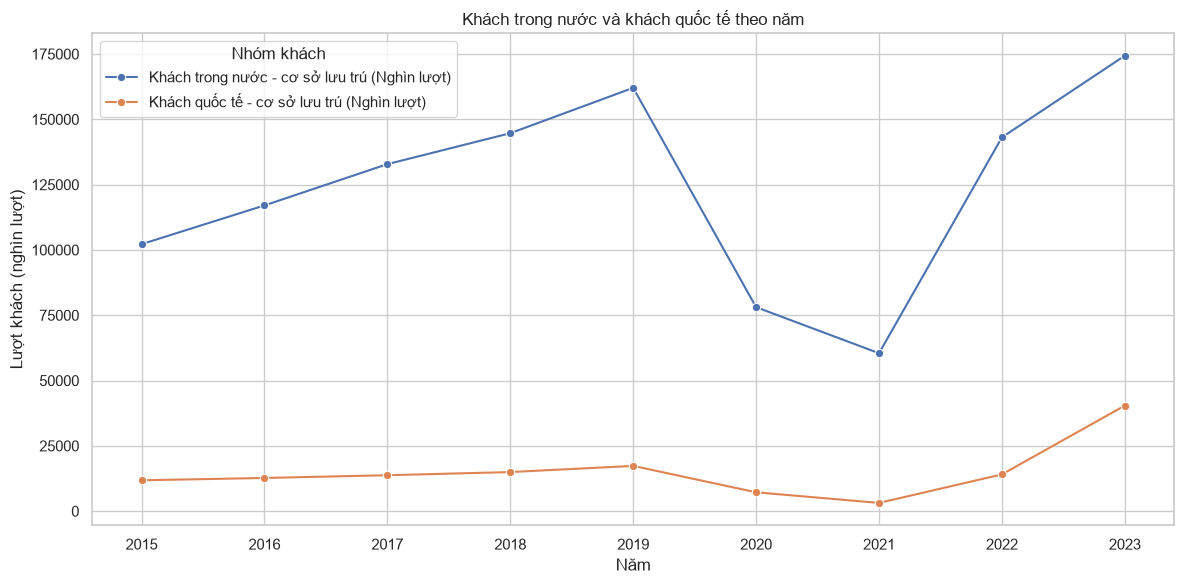

In [45]:
# 6.2. So sánh khách trong nước và khách quốc tế
plot_df = df_nam_clean[["Năm", "Khách trong nước - cơ sở lưu trú (Nghìn lượt)", "Khách quốc tế - cơ sở lưu trú (Nghìn lượt)"]].copy()
plot_df = plot_df.melt(
    id_vars="Năm",
    var_name="Nhóm khách",
    value_name="Lượt khách"
)

plt.figure(figsize=(12,6))
sns.lineplot(data=plot_df, x="Năm", y="Lượt khách", hue="Nhóm khách", marker="o")
plt.title("Khách trong nước và khách quốc tế theo năm")
plt.xlabel("Năm")
plt.ylabel("Lượt khách (nghìn lượt)")
plt.tight_layout()
plt.show()


### Nhận xét chính

- Hoạt động du lịch có xu hướng tăng trong giai đoạn trước năm 2020.
- Giai đoạn 2020–2021 ghi nhận mức suy giảm mạnh, phù hợp với bối cảnh COVID-19.
- Từ năm 2022, các chỉ tiêu khách và doanh thu có xu hướng phục hồi.
- Khách trong nước thường chiếm quy mô lớn hơn khách quốc tế.
- Khách quốc tế có mức biến động mạnh hơn và phục hồi rõ rệt sau năm 2022.


## 7. Phân tích doanh thu theo địa phương

Dataset địa phương gồm nhiều địa phương qua nhiều năm. Để biểu đồ dễ đọc, nhóm tập trung trước vào Top 10 địa phương theo doanh thu ở năm gần nhất trong dữ liệu.


In [46]:
# 7.1. Xác định năm gần nhất
latest_year = int(df_dia_phuong_clean["Năm"].dropna().max())
print("Năm gần nhất trong dữ liệu:", latest_year)

top10 = (
    df_dia_phuong_clean[df_dia_phuong_clean["Năm"] == latest_year]
    .dropna(subset=["Doanh thu du lịch lữ hành (Tỷ đồng)"])
    .sort_values("Doanh thu du lịch lữ hành (Tỷ đồng)", ascending=False)
    .head(10)
)

display(top10[["Địa phương", "Năm", "Doanh thu du lịch lữ hành (Tỷ đồng)"]])


Năm gần nhất trong dữ liệu: 2024


,Địa phương,Năm,Doanh thu du lịch lữ hành (Tỷ đồng)
9,CẢ NƯỚC,2024,"78,990.47"
499,Đông Nam Bộ,2024,"32,412.26"
559,TP. Hồ Chí Minh,2024,"31,305.00"
19,Đồng bằng sông Hồng,2024,"29,635.81"
29,Hà Nội,2024,"25,259.42"
289,Bắc Trung Bộ và Duyên hải miền Trung,2024,"12,906.67"
359,Đà Nẵng,2024,"5,460.89"
409,Khánh Hòa,2024,"4,285.32"
569,Đồng bằng sông Cửu Long,2024,"2,691.64"
59,Quảng Ninh,2024,"1,269.46"


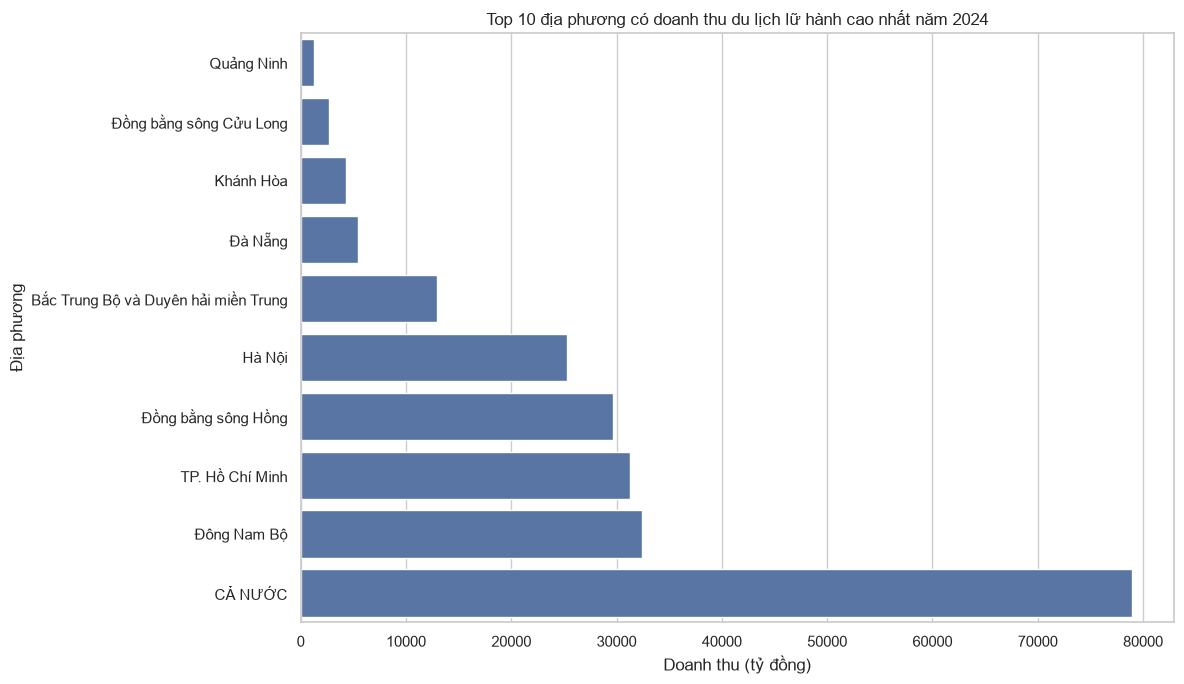

In [47]:
# 7.2. Biểu đồ Top 10 địa phương
plt.figure(figsize=(12,7))
sns.barplot(
    data=top10.sort_values("Doanh thu du lịch lữ hành (Tỷ đồng)", ascending=True),
    x="Doanh thu du lịch lữ hành (Tỷ đồng)",
    y="Địa phương"
)
plt.title(f"Top 10 địa phương có doanh thu du lịch lữ hành cao nhất năm {latest_year}")
plt.xlabel("Doanh thu (tỷ đồng)")
plt.ylabel("Địa phương")
plt.tight_layout()
plt.show()


In [ ]:
# 7.3. Plotly tương tác

import plotly.express as px
import plotly.io as pio

# Hiển thị Plotly trên trình duyệt mặc định
pio.renderers.default = "browser"

fig = px.bar(
    top10.sort_values("Doanh thu du lịch lữ hành (Tỷ đồng)", ascending=True),
    x="Doanh thu du lịch lữ hành (Tỷ đồng)",
    y="Địa phương",
    orientation="h",
    title=f"Top 10 địa phương có doanh thu du lịch lữ hành cao nhất năm {latest_year}",
    labels={
        "Doanh thu du lịch lữ hành (Tỷ đồng)": "Doanh thu (tỷ đồng)",
        "Địa phương": "Địa phương"
    },
    hover_data=["Năm"]
)

fig.show()

### Nhận xét

Biểu đồ Top 10 giúp làm nổi bật sự khác biệt về doanh thu giữa các địa phương. Các trung tâm du lịch và đô thị lớn có xu hướng nằm trong nhóm dẫn đầu. Việc sử dụng biểu đồ cột ngang giúp đọc tên địa phương thuận tiện hơn khi số lượng nhóm tương đối nhiều.

Với Plotly, người xem có thể di chuột để xem giá trị cụ thể, giúp tăng khả năng khai thác dữ liệu so với biểu đồ tĩnh.


## 8. Phân tích sâu hơn: doanh thu theo thời gian của một số địa phương

Ngoài việc xếp hạng tại một năm, có thể quan sát sự thay đổi của các địa phương nổi bật qua toàn bộ giai đoạn.


In [49]:
# 8.1. Chọn Top 5 địa phương theo doanh thu ở năm gần nhất
top5_places = top10.head(5)["Địa phương"].tolist()
trend_dp = df_dia_phuong_clean[
    df_dia_phuong_clean["Địa phương"].isin(top5_places)
].dropna(subset=["Doanh thu du lịch lữ hành (Tỷ đồng)"])

display(trend_dp.head())


,Địa phương,Cấp dữ liệu,Năm,Trạng thái,Doanh thu du lịch lữ hành (Tỷ đồng)
0,CẢ NƯỚC,Cả nước,2015,Chính thức,"30,444.10"
1,CẢ NƯỚC,Cả nước,2016,Chính thức,"32,530.30"
2,CẢ NƯỚC,Cả nước,2017,Chính thức,"36,111.80"
3,CẢ NƯỚC,Cả nước,2018,Chính thức,"40,371.20"
4,CẢ NƯỚC,Cả nước,2019,Chính thức,"44,669.90"


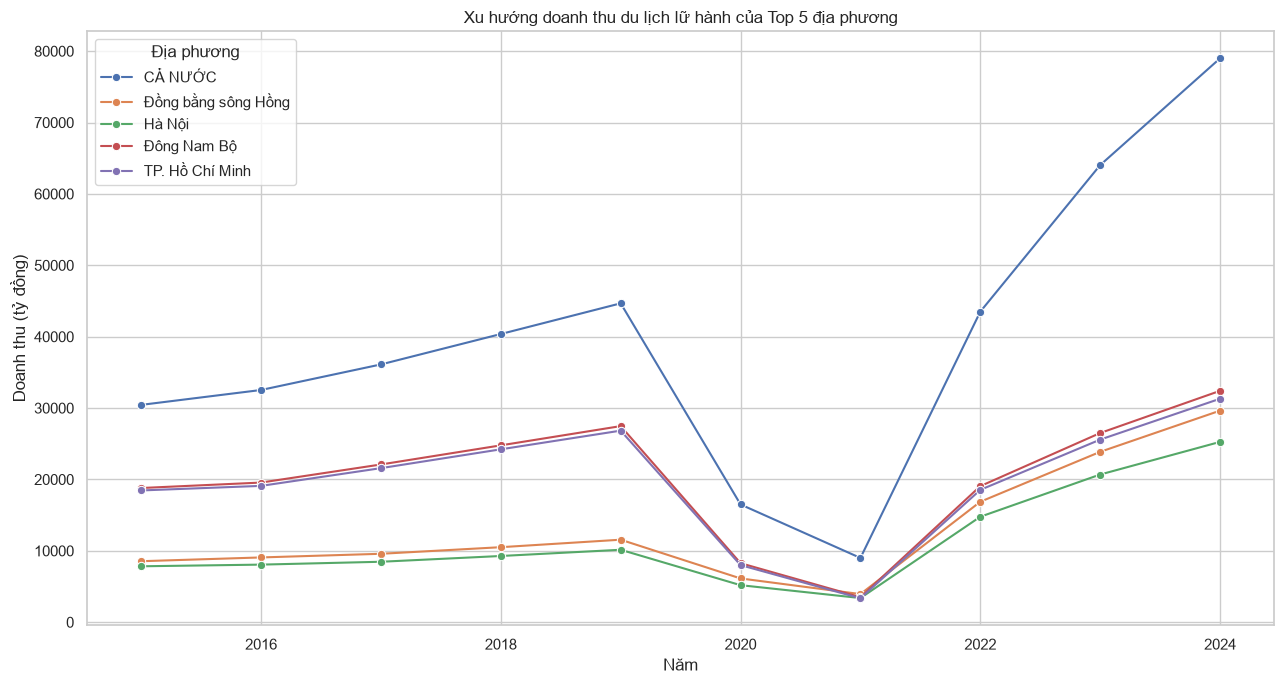

In [50]:
# 8.2. Biểu đồ xu hướng Top 5 địa phương
plt.figure(figsize=(13,7))
sns.lineplot(
    data=trend_dp,
    x="Năm",
    y="Doanh thu du lịch lữ hành (Tỷ đồng)",
    hue="Địa phương",
    marker="o"
)
plt.title("Xu hướng doanh thu du lịch lữ hành của Top 5 địa phương")
plt.xlabel("Năm")
plt.ylabel("Doanh thu (tỷ đồng)")
plt.tight_layout()
plt.show()


## 9. Tổng hợp các phát hiện chính

1. Dữ liệu du lịch theo năm cho phép quan sát rõ xu hướng tăng trưởng, suy giảm và phục hồi của ngành.
2. Giai đoạn 2020–2021 là điểm biến động lớn nhất trong chuỗi thời gian.
3. Từ năm 2022, hoạt động du lịch phục hồi rõ rệt.
4. Khách trong nước có quy mô lớn, trong khi khách quốc tế biến động mạnh hơn.
5. Doanh thu du lịch có sự khác biệt đáng kể giữa các địa phương.
6. Một số trung tâm du lịch lớn nổi bật về doanh thu.
7. Biểu đồ tĩnh phù hợp với các phân tích tổng quan; Plotly phù hợp khi cần khám phá chi tiết từng địa phương hoặc từng năm.
